# Experimento 1: generación del pool de relaciones a partir de contexto real

En este notebook se construye un pool de relaciones candidatas utilizando como unidad de análisis el verbo junto con su contexto oracional.

Este experimento parte de la limitación observada en pruebas anteriores: el verbo aislado no siempre contiene información suficiente para agrupar correctamente relaciones semánticas.

Por ello, en este experimento se utiliza:

- el verbo lematizado,
- la oración completa en la que aparece,
- embeddings semánticos del contexto,
- clustering no supervisado mediante HDBSCAN.

El objetivo es evaluar si el contexto real mejora la agrupación de verbalizaciones equivalentes y permite obtener un primer pool de relaciones candidatas para la construcción incremental de la ontología.

In [92]:
# ============================================================
# EXPERIMENTO 1
# Generación del pool de relaciones a partir de contexto real
# ============================================================
# En esta celda se centralizan los parámetros principales del
# experimento para que el notebook sea más fácil de reproducir
# y modificar.

# Identificador del experimento.
# Se usará como prefijo en los ficheros de salida.
EXPERIMENTO = "Exp01"

# Carpeta donde se guardarán los resultados generados.
OUTPUT_DIR = "../Output/experiments"

# Modelo de embeddings utilizado para representar semánticamente
# las oraciones en las que aparece cada verbo.
MODEL_EMBEDDINGS = "paraphrase-multilingual-MiniLM-L12-v2"

# Parámetros principales de HDBSCAN.
# min_cluster_size define el tamaño mínimo que debe tener un cluster.
MIN_CLUSTER_SIZE = 4

# min_samples controla la exigencia del algoritmo para considerar
# un punto como parte de una zona densa.
MIN_SAMPLES = 2

# Semilla para mantener reproducibilidad en aquellos procesos
# que puedan depender de aleatoriedad.
RANDOM_STATE = 42

In [93]:
# ============================================================
# IMPORTS
# ============================================================

import os
import re

import pandas as pd
import numpy as np

import spacy

from sentence_transformers import SentenceTransformer

import hdbscan

import matplotlib.pyplot as plt


# ============================================================
# CREACIÓN DE CARPETAS DE SALIDA
# ============================================================

# Si la carpeta Outputs no existe, se crea automáticamente.
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# CARGA DEL MODELO LINGÜÍSTICO
# ============================================================

# Modelo lingüístico de spaCy para español.
nlp = spacy.load("es_core_news_lg")


# ============================================================
# CARGA DEL MODELO DE EMBEDDINGS
# ============================================================

# Modelo multilingüe utilizado para representar semánticamente
# las oraciones extraídas del corpus.
model_embeddings = SentenceTransformer(MODEL_EMBEDDINGS)


print("Configuración cargada correctamente.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Configuración cargada correctamente.


In [94]:
# ============================================================
# CARGA DEL DATASET
# ============================================================

# Ruta del dataset limpio procedente del TFM anterior.
DATASET_PATH = "../Data/DicatJuanRana_Dataset.csv"

# Carga del CSV.
df = pd.read_csv(DATASET_PATH, sep=";")

print("Dataset cargado correctamente.")
print(f"Número de registros: {len(df)}")
print(f"Número de columnas: {df.shape[1]}")

# Mostrar primeras filas.
df.head()

Dataset cargado correctamente.
Número de registros: 38
Número de columnas: 4


,year,text,sentences,clarified_sentences
0,0,"Aunque su verdadero nombre era Cosme Pérez, fu...","[""Aunque su verdadero nombre era Cosme Pérez, ...","[""Aunque su verdadero nombre era Cosme Pérez, ..."
1,1617,"Según Cotarelo , a quien sigue Sáez Raposo , C...","['Según Cotarelo, a quien sigue Sáez Raposo, ...","['Según Cotarelo, a quien sigue Sáez Raposo, S..."
2,1621,Consta la lista de la compañía de Juan Bautist...,['Consta la lista de la compañía de Juan Bauti...,['Consta la lista de la compañía de Juan Bauti...
3,1624,Cosme Pérez aparece en la nómina de la compañí...,['Cosme Pérez aparece en la nómina de la compa...,['Cosme Pérez aparece en la nómina de la compa...
4,1634,"Según Cotarelo, Cosme Pérez pertenecía a la co...","['Según Cotarelo, Cosme Pérez pertenecía a la ...","['Según Cotarelo, Cosme Pérez pertenecía a la ..."


In [95]:
# ============================================================
# SELECCIÓN DE LA COLUMNA TEXTUAL
# ============================================================
# Para este experimento utilizamos la columna clarified_sentences,
# ya que contiene las frases clarificadas del dataset limpio.

TEXT_COLUMN = "clarified_sentences"

# Comprobamos cuántos valores nulos hay en la columna seleccionada.
num_nulls = df[TEXT_COLUMN].isna().sum()

print(f"Columna textual seleccionada: {TEXT_COLUMN}")
print(f"Valores nulos en la columna: {num_nulls}")

# Nos quedamos únicamente con los registros que tienen texto válido.
df_text = df.dropna(subset=[TEXT_COLUMN]).copy()

print(f"Número de registros con texto válido: {len(df_text)}")

df_text[[TEXT_COLUMN]].head()

Columna textual seleccionada: clarified_sentences
Valores nulos en la columna: 0
Número de registros con texto válido: 38


,clarified_sentences
0,"[""Aunque su verdadero nombre era Cosme Pérez, ..."
1,"['Según Cotarelo, a quien sigue Sáez Raposo, S..."
2,['Consta la lista de la compañía de Juan Bauti...
3,['Cosme Pérez aparece en la nómina de la compa...
4,"['Según Cotarelo, Cosme Pérez pertenecía a la ..."


In [96]:
# ============================================================
# LIMPIEZA MÍNIMA DEL TEXTO
# ============================================================
# Esta función utiliza spaCy para limpiar el texto a nivel de token.
# Conserva únicamente tokens alfabéticos y elimina puntuación,
# espacios, símbolos y otros elementos no lingüísticos.

def clean_text(text):
    doc = nlp(str(text))

    clean_tokens = [
        token.text
        for token in doc
        if token.is_alpha
        and not token.is_punct
        and not token.is_space
    ]

    return " ".join(clean_tokens)


df_text["texto_limpio"] = df_text[TEXT_COLUMN].apply(clean_text)

print("Limpieza mínima aplicada correctamente.")

df_text[[TEXT_COLUMN, "texto_limpio"]].head()

Limpieza mínima aplicada correctamente.


,clarified_sentences,texto_limpio
0,"[""Aunque su verdadero nombre era Cosme Pérez, ...",Aunque su verdadero nombre era Cosme Pérez Cos...
1,"['Según Cotarelo, a quien sigue Sáez Raposo, S...",Según Cotarelo a quien sigue Sáez Raposo Sáez ...
2,['Consta la lista de la compañía de Juan Bauti...,Consta la lista de la compañía de Juan Bautist...
3,['Cosme Pérez aparece en la nómina de la compa...,Cosme Pérez aparece en la nómina de la compañí...
4,"['Según Cotarelo, Cosme Pérez pertenecía a la ...",Según Cotarelo Cosme Pérez pertenecía a la com...


In [97]:
# ============================================================
# EXTRACCIÓN DE VERBOS CON CONTEXTO ORACIONAL
# ============================================================
# En esta celda se procesa cada texto con spaCy y se extraen los verbos.
# Para cada verbo se guarda:
# - la forma original encontrada en el texto,
# - el lema verbal,
# - la oración completa en la que aparece,
# - el año asociado al registro.
#
# La oración completa se utilizará como contexto real para generar embeddings.

def extract_verbs_with_sentence_context(row):
    """
    Extrae verbos de un registro textual junto con su contexto oracional.

    Parameters
    ----------
    row : pandas.Series
        Fila del dataframe que contiene el año y el texto limpio.

    Returns
    -------
    list[dict]
        Lista de verbos extraídos con su información contextual.
    """

    year = row["year"]
    text = row["texto_limpio"]

    doc = nlp(text)

    extracted_verbs = []

    for token in doc:

        # Seleccionamos únicamente verbos.
        # Se excluyen tokens no alfabéticos para reducir ruido.
        if token.pos_ == "VERB" and token.is_alpha:

            extracted_verbs.append({
                "year": year,
                "verbo_texto": token.text,
                "verbo_lema": token.lemma_,
                "contexto_oracional": token.sent.text.strip()
            })

    return extracted_verbs


# Aplicamos la extracción a todos los registros del dataset.
all_verbs = []

for _, row in df_text.iterrows():
    all_verbs.extend(extract_verbs_with_sentence_context(row))


# Convertimos el resultado a dataframe.
df_verbs = pd.DataFrame(all_verbs)

print("Extracción verbal completada.")
print(f"Número total de apariciones verbales extraídas: {len(df_verbs)}")
print(f"Número de verbos únicos lematizados: {df_verbs['verbo_lema'].nunique()}")

df_verbs.head()

Extracción verbal completada.
Número total de apariciones verbales extraídas: 1022
Número de verbos únicos lematizados: 295


,year,verbo_texto,verbo_lema,contexto_oracional
0,0,conocido,conocer,Aunque su verdadero nombre era Cosme Pérez Cos...
1,0,documenta,documentar,Aunque su verdadero nombre era Cosme Pérez Cos...
2,0,aplicaba,aplicar,Aunque su verdadero nombre era Cosme Pérez Cos...
3,0,aventuró,aventurar,Aunque su verdadero nombre era Cosme Pérez Cos...
4,0,nacido,nacer,Aunque su verdadero nombre era Cosme Pérez Cos...


In [100]:
# ============================================================
# ELIMINACIÓN DE DUPLICADOS
# ============================================================
# Eliminamos duplicados exactos de verbo + contexto oracional.
# Esto evita que una misma aparición textual repetida pese varias veces
# en el cálculo de embeddings y en el clustering.

df_relaciones = (
    df_verbs
    .drop_duplicates(subset=["verbo_lema", "contexto_oracional"])
    .reset_index(drop=True)
)

print("Duplicados eliminados.")
print(f"Apariciones verbales originales: {len(df_verbs)}")
print(f"Relaciones verbo-contexto únicas: {len(df_relaciones)}")
print(f"Verbos únicos lematizados: {df_relaciones['verbo_lema'].nunique()}")

df_relaciones.head()

Duplicados eliminados.
Apariciones verbales originales: 1022
Relaciones verbo-contexto únicas: 666
Verbos únicos lematizados: 295


,year,verbo_texto,verbo_lema,contexto_oracional
0,0,conocido,conocer,Aunque su verdadero nombre era Cosme Pérez Cos...
1,0,documenta,documentar,Aunque su verdadero nombre era Cosme Pérez Cos...
2,0,aplicaba,aplicar,Aunque su verdadero nombre era Cosme Pérez Cos...
3,0,aventuró,aventurar,Aunque su verdadero nombre era Cosme Pérez Cos...
4,0,nacido,nacer,Aunque su verdadero nombre era Cosme Pérez Cos...


In [ ]:
# ============================================================
# TEXTO DE ENTRADA PARA LOS EMBEDDINGS
# ============================================================
# En lugar de representar únicamente la oración completa,
# combinamos el verbo lematizado con su contexto oracional.
#
# Esto intenta evitar que el modelo agrupe solo por tema narrativo
# y fuerza a que el verbo tenga peso dentro de la representación.

df_relaciones["texto_embedding"] = (
    #df_relaciones["verbo_lema"] + " : " + df_relaciones["contexto_oracional"]
    df_relaciones["verbo_texto"] + " : " + df_relaciones["contexto_oracional"]
)

df_relaciones[[
    "verbo_texto",
    "contexto_oracional",
    "texto_embedding"
]].head()

,verbo_texto,contexto_oracional,texto_embedding
0,conocido,Aunque su verdadero nombre era Cosme Pérez Cos...,conocido : Aunque su verdadero nombre era Cosm...
1,documenta,Aunque su verdadero nombre era Cosme Pérez Cos...,documenta : Aunque su verdadero nombre era Cos...
2,aplicaba,Aunque su verdadero nombre era Cosme Pérez Cos...,aplicaba : Aunque su verdadero nombre era Cosm...
3,aventuró,Aunque su verdadero nombre era Cosme Pérez Cos...,aventuró : Aunque su verdadero nombre era Cosm...
4,nacido,Aunque su verdadero nombre era Cosme Pérez Cos...,nacido : Aunque su verdadero nombre era Cosme ...


: 

In [77]:
# ============================================================
# GENERACIÓN DE EMBEDDINGS SEMÁNTICOS
# ============================================================
# Generamos una representación vectorial para cada contexto oracional.
# La unidad semántica del experimento no es solo el verbo aislado,
# sino el verbo dentro de la oración en la que aparece.

contextos = df_relaciones["texto_embedding"].tolist()

embeddings = model_embeddings.encode(
    contextos,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embeddings generados correctamente.")
print(f"Número de embeddings: {embeddings.shape[0]}")
print(f"Dimensión de cada embedding: {embeddings.shape[1]}")

Batches:   0%|          | 0/21 [00:00<?, ?it/s]

Embeddings generados correctamente.
Número de embeddings: 666
Dimensión de cada embedding: 384


In [78]:
# ============================================================
# CLUSTERING SEMÁNTICO CON HDBSCAN
# ============================================================
# Aplicamos HDBSCAN sobre los embeddings generados a partir
# del contexto oracional de cada relación verbal.

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric="euclidean"
)

clusters = clusterer.fit_predict(embeddings)

# Añadimos los clusters al dataframe.
df_relaciones["cluster"] = clusters

print("Clustering completado correctamente.")

# ============================================================
# MÉTRICAS GENERALES
# ============================================================

total_relaciones = len(df_relaciones)

# Número de clusters reales (excluyendo ruido = -1)
total_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

# Número de relaciones clasificadas como ruido
total_noise = (clusters == -1).sum()

# Porcentaje de ruido
noise_percentage = round(
    total_noise / total_relaciones * 100,
    2
)

print(f"Relaciones analizadas: {total_relaciones}")
print(f"Clusters detectados: {total_clusters}")
print(f"Relaciones clasificadas como ruido: {total_noise}")
print(f"Porcentaje de ruido: {noise_percentage}%")

Clustering completado correctamente.
Relaciones analizadas: 666
Clusters detectados: 36
Relaciones clasificadas como ruido: 15
Porcentaje de ruido: 2.25%


In [79]:
# ============================================================
# INSPECCIÓN DE CLUSTERS
# ============================================================
# Mostramos las relaciones agrupadas en cada cluster
# para analizar coherencia semántica.

for cluster_id in sorted(df_relaciones["cluster"].unique()):

    # Ignoramos ruido
    if cluster_id == -1:
        continue

    print("=" * 60)
    print(f"CLUSTER {cluster_id}")
    print("=" * 60)

    cluster_data = df_relaciones[
        df_relaciones["cluster"] == cluster_id
    ]

    verbos_cluster = sorted(
        cluster_data["verbo_lema"].unique()
    )

    print(verbos_cluster[:30])

    print(f"\nNúmero de relaciones: {len(cluster_data)}")
    print(f"Número de verbos únicos: {len(verbos_cluster)}")

    print("\n")

CLUSTER 0
['contener', 'costar', 'hacer', 'mantener', 'requerir', 'seguir', 'tratar']

Número de relaciones: 7
Número de verbos únicos: 7


CLUSTER 1
['acudir', 'apuntar', 'constar', 'dar', 'dar él', 'decir', 'estar', 'gozar', 'guardar', 'hacer', 'imitar', 'informar', 'interpretar', 'intervenir', 'participar', 'permitir', 'reflejar', 'representar', 'reunir', 'reír', 'servir', 'sobrevenir', 'tener', 'ver', 'volver']

Número de relaciones: 25
Número de verbos únicos: 25


CLUSTER 2
['abarcar', 'acabar', 'aclarar', 'actuar', 'acusar', 'asistir', 'celebrar', 'citar', 'constar', 'contener', 'corregir', 'creer', 'deber', 'declarar', 'deducir él', 'dejar', 'emplear', 'encontrar', 'encontrar él', 'enviar', 'escribir', 'fallecer', 'figurar', 'hacer', 'identificar', 'indicar', 'informar él', 'intervenir', 'nacer', 'pagar']

Número de relaciones: 38
Número de verbos únicos: 38


CLUSTER 3
['actuar', 'contener', 'mantener', 'proponer', 'requerir']

Número de relaciones: 5
Número de verbos únicos: 

In [85]:
# ============================================================
# MÉTRICAS BÁSICAS DE CLUSTERS
# ============================================================
# Calculamos métricas básicas para analizar el comportamiento
# de los clusters generados por HDBSCAN.

cluster_metrics = []

# Recorremos todos los clusters excepto ruido (-1).
for cluster_id in sorted(df_relaciones["cluster"].unique()):

    if cluster_id == -1:
        continue

    cluster_data = df_relaciones[
        df_relaciones["cluster"] == cluster_id
    ]

    # Número total de relaciones en el cluster.
    total_relaciones_cluster = len(cluster_data)

    # Número de verbos únicos.
    verbos_unicos = cluster_data["verbo_lema"].nunique()

    # Frecuencia media de reutilización verbal.
    frecuencia_media = (
        total_relaciones_cluster / verbos_unicos
    )

    # Lista de verbos únicos del cluster.
    lista_verbos = sorted(
        cluster_data["verbo_lema"].unique()
    )

    cluster_metrics.append({
        "cluster": cluster_id,
        "num_relaciones": total_relaciones_cluster,
        "num_verbos_unicos": verbos_unicos,
        "frecuencia_media": round(frecuencia_media, 2),
        "verbos": ", ".join(lista_verbos[:20])
    })

# Convertimos a dataframe.
df_cluster_metrics = pd.DataFrame(cluster_metrics)

# Ordenamos por tamaño del cluster.
df_cluster_metrics = df_cluster_metrics.sort_values(
    by="num_relaciones",
    ascending=False
).reset_index(drop=True)

print("Métricas de clusters calculadas correctamente.")

df_cluster_metrics.head(10)

Métricas de clusters calculadas correctamente.


,cluster,num_relaciones,num_verbos_unicos,frecuencia_media,verbos
0,6,158,158,1.0,"acabar, aconsejar, actualizar, actuar, acusar,..."
1,2,38,38,1.0,"abarcar, acabar, aclarar, actuar, acusar, asis..."
2,20,36,36,1.0,"acompañar, aparecer, comprometer él, constar, ..."
3,4,34,34,1.0,"acompañar, afirmar, apuntar, compartir, concer..."
4,1,25,25,1.0,"acudir, apuntar, constar, dar, dar él, decir, ..."
5,23,24,24,1.0,"alabar, arrimar, cantar, constar, costar, dar,..."
6,28,23,23,1.0,"asistir, decir, declarar, destacar, destar, en..."
7,31,21,21,1.0,"cobrar, dar, decir, eliminar, estar, hacer, in..."
8,35,21,21,1.0,"acudir, compartir, confirmar, conservar, cumpl..."
9,11,19,19,1.0,"actuar, anotar, aventurar, cantar, constar, cu..."


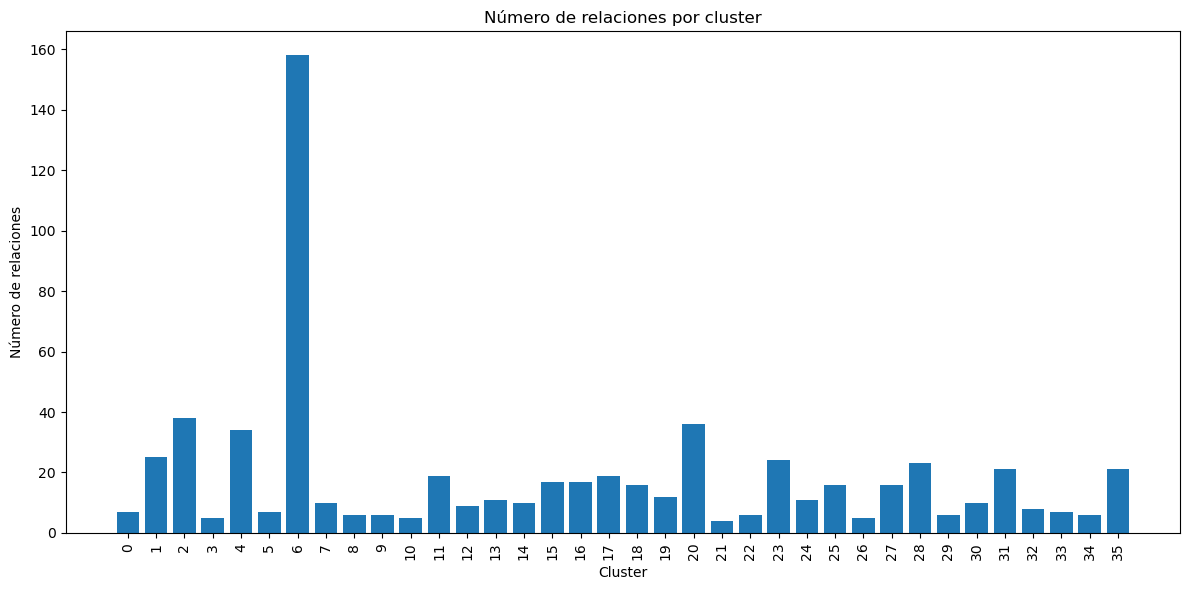

In [86]:
# ============================================================
# TAMAÑO DE LOS CLUSTERS
# ============================================================
# Visualización del número de relaciones detectadas
# en cada cluster generado por HDBSCAN.

# Ordenamos clusters por tamaño.
df_plot = df_cluster_metrics.sort_values(
    by="cluster",
    ascending=True
)

plt.figure(figsize=(12, 6))

plt.bar(
    df_plot["cluster"].astype(str),
    df_plot["num_relaciones"]
)

plt.title("Número de relaciones por cluster")
plt.xlabel("Cluster")
plt.ylabel("Número de relaciones")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [91]:
# ============================================================
# COHERENCIA SEMÁNTICA INTRA-CLUSTER
# ============================================================
# Calculamos la similitud media entre los embeddings de cada cluster.
#
# Importante:
# Cada embedding se asocia explícitamente a su fila correspondiente
# para evitar desalineaciones entre índices del dataframe y posiciones
# del array de embeddings.

from sklearn.metrics.pairwise import cosine_similarity

# Guardamos cada embedding dentro del dataframe de relaciones.
# Esto garantiza que cada fila conserva su representación vectorial.
df_relaciones["embedding"] = list(embeddings)

cluster_coherence = []

for cluster_id in sorted(df_relaciones["cluster"].unique()):

    # Ignoramos el ruido.
    if cluster_id == -1:
        continue

    # Filtramos las relaciones pertenecientes al cluster actual.
    cluster_data = df_relaciones[
        df_relaciones["cluster"] == cluster_id
    ]

    # Recuperamos los embeddings asociados a esas filas.
    cluster_embeddings = np.vstack(
        cluster_data["embedding"].values
    )

    # Si el cluster tiene menos de 2 elementos, no se puede calcular coherencia.
    if len(cluster_embeddings) < 2:
        coherence = np.nan
    else:
        sim_matrix = cosine_similarity(cluster_embeddings)

        # Extraemos solo la parte superior de la matriz, excluyendo la diagonal.
        # Así evitamos comparar cada embedding consigo mismo.
        sim_values = sim_matrix[
            np.triu_indices_from(sim_matrix, k=1)
        ]

        coherence = sim_values.mean()

    cluster_coherence.append({
        "cluster": cluster_id,
        "coherencia_semantica": coherence
    })

df_cluster_coherence = pd.DataFrame(cluster_coherence)

# Eliminamos una posible columna previa de coherencia si la celda se reejecuta.
df_cluster_metrics = df_cluster_metrics.drop(
    columns=["coherencia_semantica"],
    errors="ignore"
)

# Unimos la coherencia con las métricas básicas de cluster.
df_cluster_metrics = df_cluster_metrics.merge(
    df_cluster_coherence,
    on="cluster",
    how="left"
)

# Ordenamos por coherencia semántica.
df_cluster_metrics = df_cluster_metrics.sort_values(
    by="coherencia_semantica",
    ascending=True
).reset_index(drop=True)

df_cluster_metrics.head(15)


,cluster,num_relaciones,num_verbos_unicos,frecuencia_media,verbos,coherencia_semantica
0,17,19,18,1.06,"acordar, acudir, aparecer, concertarar, consta...",0.937388
1,33,7,4,1.75,"acudir, llevar, organizar, recibir",0.966363
2,11,19,19,1.00,"actuar, anotar, aventurar, cantar, constar, cu...",0.971915
3,32,8,8,1.00,"actuar, bautizar, entregar, explicitar, hacer,...",0.973152
4,1,25,25,1.00,"acudir, apuntar, constar, dar, dar él, decir, ...",0.979896
5,5,7,7,1.00,"bajar, dirigir él, ocupar, participar, referir...",0.984470
6,15,17,17,1.00,"comprometer, constar, continuar, cumplir, dar ...",0.986893
7,4,34,34,1.00,"acompañar, afirmar, apuntar, compartir, concer...",0.988802
8,13,11,11,1.00,"aclarar él, acudir, bailar, concertar, constar...",0.989478
9,28,23,23,1.00,"asistir, decir, declarar, destacar, destar, en...",0.989595


In [89]:
df_cluster_metrics.tail(15)

,cluster,num_relaciones,num_verbos_unicos,frecuencia_media,verbos,coherencia_semantica
21,19,12,12,1.00,"atreveír, constar, creer, cumplir, dar, entret...",0.991192
22,20,36,36,1.00,"acompañar, aparecer, comprometer él, constar, ...",0.991163
23,29,6,6,1.00,"asistir, constar, enviar, hacer, pertenecer, v...",0.991114
24,18,16,16,1.00,"an, cobrar, comprometer, contratar, correspond...",0.990039
25,25,16,16,1.00,"acusar, constar, detener, empezar, hacer, infe...",0.989677
26,28,23,23,1.00,"asistir, decir, declarar, destacar, destar, en...",0.989595
27,13,11,11,1.00,"aclarar él, acudir, bailar, concertar, constar...",0.989478
28,4,34,34,1.00,"acompañar, afirmar, apuntar, compartir, concer...",0.988802
29,15,17,17,1.00,"comprometer, constar, continuar, cumplir, dar ...",0.986893
30,5,7,7,1.00,"bajar, dirigir él, ocupar, participar, referir...",0.984470
